In [2]:
import pandas as pd

wide = pd.read_parquet("C:\\Users\\PC\\balance-sheet-ml\\data\\processed\\wide.parquet")
print("Shape:", wide.shape)


Shape: (41859, 7669)


In [14]:
frac_present = wide.notna().mean().sort_values(ascending=False)

# Top 20 concepts les plus complets
print(frac_present.head(1000))

# Bottom 20 concepts les plus manquants
print(frac_present.tail(520))


fy                                                                                    1.000000
accn                                                                                  1.000000
fp                                                                                    1.000000
end                                                                                   1.000000
entity                                                                                1.000000
                                                                                        ...   
EffectiveIncomeTaxRateReconciliationChangeInEnactedTaxRate                            0.009675
ProceedsFromIssuanceOrSaleOfEquity                                                    0.009651
StockRepurchaseProgramAuthorizedAmount                                                0.009580
EffectiveIncomeTaxRateReconciliationNondeductibleExpenseShareBasedCompensationCost    0.009580
MarketableSecuritiesNoncurrent                    

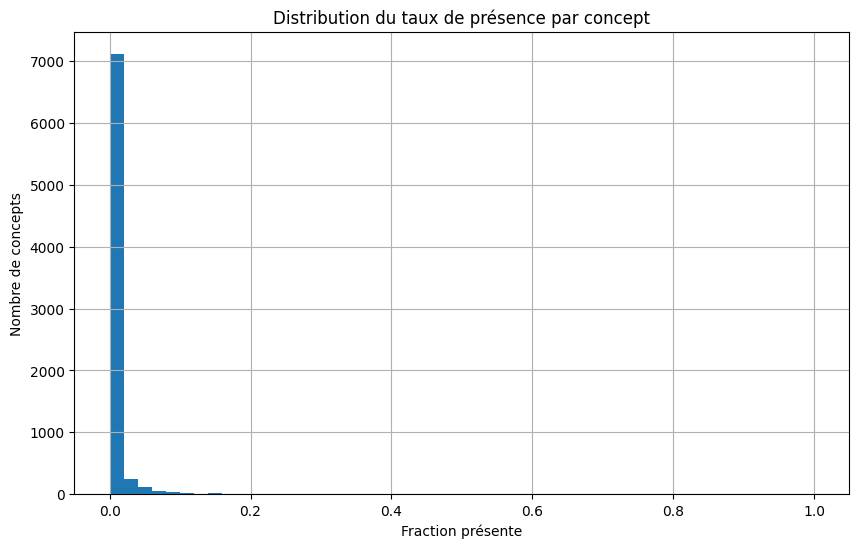

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
frac_present.hist(bins=50)
plt.title("Distribution du taux de présence par concept")
plt.xlabel("Fraction présente")
plt.ylabel("Nombre de concepts")
plt.show()


In [10]:
missing_by_cik = wide.groupby("cik").apply(lambda g: g.isna().mean().mean())
print(missing_by_cik.sort_values().head(10))   # entreprises les plus complètes
print(missing_by_cik.sort_values().tail(10))   # entreprises les plus incomplètes


cik
40729    0.983395
19617    0.984512
8177     0.984808
36104    0.984953
9342     0.985135
20286    0.985373
4904     0.985554
40554    0.985556
39263    0.985693
4962     0.985997
dtype: float64
cik
23503         0.996610
21239         0.996647
40194         0.996948
44689         0.997237
42284         0.997355
1961          0.997546
3952          0.998001
40730         0.998060
3982          0.998174
0000027430    0.998500
dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_10880\1299731126.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cik = wide.groupby("cik").apply(lambda g: g.isna().mean().mean())


In [24]:
frac_present = wide.notna().mean()

# Tester plusieurs seuils
for t in [0.001,0.005,0.01,0.05,0.1, 0.2, 0.3, 0.4]:
    keep_cols = frac_present[frac_present > t].index.tolist()
    print(f"Threshold {t*100:0.0f}% → {len(keep_cols)} features retenus")

Threshold 0% → 3836 features retenus
Threshold 0% → 1570 features retenus
Threshold 1% → 982 features retenus
Threshold 5% → 244 features retenus
Threshold 10% → 109 features retenus
Threshold 20% → 42 features retenus
Threshold 30% → 15 features retenus
Threshold 40% → 6 features retenus


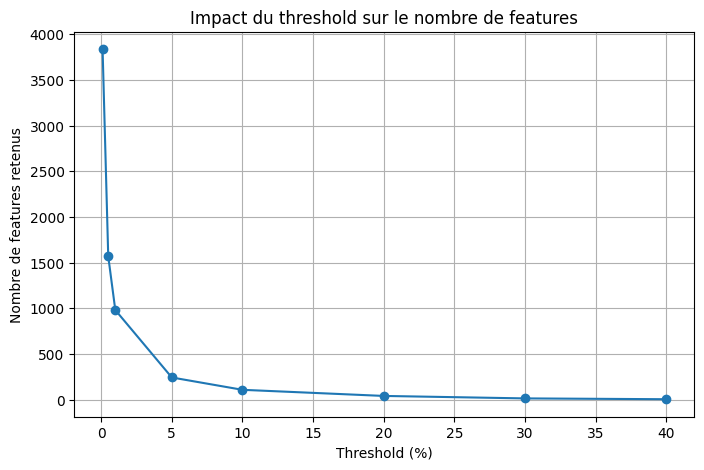

In [25]:
import matplotlib.pyplot as plt

thresholds = [0.1, 0.5, 1, 5, 10, 20, 30, 40]
features_retained = [3836, 1570, 982, 244, 109, 42, 15, 6]

plt.figure(figsize=(8,5))
plt.plot(thresholds, features_retained, marker="o")
plt.title("Impact du threshold sur le nombre de features")
plt.xlabel("Threshold (%)")
plt.ylabel("Nombre de features retenus")
plt.grid(True)
plt.show()
